# Машинное обучение, ФКН ВШЭ
## Практическое задание 4.

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Задание выполняется самостоятельно.

В финальной версии ноутбука, которая отправляется для сдачи задания, должны быть быть выполнены следующие условия:
* все ячейки выполнены для представленной в ноутбуке версии кода
* результаты выполнения ячеек отображены и согласованы с кодом
* при повторном запуске ячеек результаты должны воспроизводиться с точностью до случайности

### Формат сдачи
Для сдачи задания переименуйте получившийся файл \*.ipynb в соответствии со следующим форматом: *HW1_Username.ipynb*, где *Username* — Ваша фамилия и инициалы на латинице (например, *HW1_IvanovII.ipynb*). Далее отправьте этот файл на Smorodinov-1990@mail.ru.

## Кластеризация

Задача [кластеризации](https://en.wikipedia.org/wiki/Cluster_analysis) данных является одним из примеров задач обучения "без учителя". Она заключается в разбиении множества объектов на заданное число кластеров, при этом предполагается, что внутри одного кластера будут находиться похожие между собой объекты. Одним из примеров методов кластеризации является алгоритм [KMeans](https://en.wikipedia.org/wiki/K-means_clustering).

### Выбор числа кластеров

Для некоторых алгоритмов кластеризации число кластеров является гиперпараметром (например, в случае KMeans). Поэтому для выбора количества кластеров может быть использован следующий подход: при фиксированной метрике качества для разного числа кластеров обучают алгоритм и выбирают то значение гиперпараметра, начиная с которого качество "стабилизируется".

### Метрики качества

Оценивание качества построенной кластеризации — не всегда тривиальная задача, поскольку следует учитывать ряд фактов:
 - объекты одного класса должны быть более похожи друг на друга, чем на объекты других кластеров, относительно некоторой заданной метрики похожести;
 - метрика не должна учитывать истинные значения меток объектов, попавших в кластер (в случае, если истинные метки известны).

При выполнении задания для оценки качества получившейся кластеризации воспользуемся следующими метриками:
 - [Homogeneity и Completeness](http://scikit-learn.org/stable/modules/clustering.html#homogeneity-completeness-and-v-measure) 
 - [Adjusted Rand index](http://scikit-learn.org/stable/modules/clustering.html#rand-index) 
 - [Silhouette Coefficient](http://scikit-learn.org/stable/modules/clustering.html#silhouette-coefficient)

Загрузите набор данных [digits](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html). Перед применением алгоритмов не забудьте перемешать изображения в случайном порядке.

In [1]:
from sklearn.datasets import load_digits
import numpy as np
from sklearn.utils import shuffle

X, y = load_digits(return_X_y=True)
X, y = shuffle(X, y, random_state=42)

# import matplotlib.pyplot as plt
# plt.imshow(X[0].reshape(8, 8), cmap='gray')
# plt.title(f'Label: {y[0]}')
# plt.show()

**1. (1 балл)** Кластеризуйте изображения при помощи алгоритма [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), подобрав число кластеров для любой фиксированной метрики из указанных выше. Рассмотрите различные способы выбора начального приближения (параметр *init*). Оцените качество получившейся кластеризации, используя все описанные выше метрики. Визуализируйте изображения, соответствующие центроидам лучшей кластеризации.

Init: k-means++
Homogeneity: 0.740
Completeness: 0.748
Adjusted Rand Index: 0.668
Silhouette Coefficient: 0.182
------------------------------
Init: random
Homogeneity: 0.741
Completeness: 0.750
Adjusted Rand Index: 0.669
Silhouette Coefficient: 0.183
------------------------------
Лучшая инициализация: random


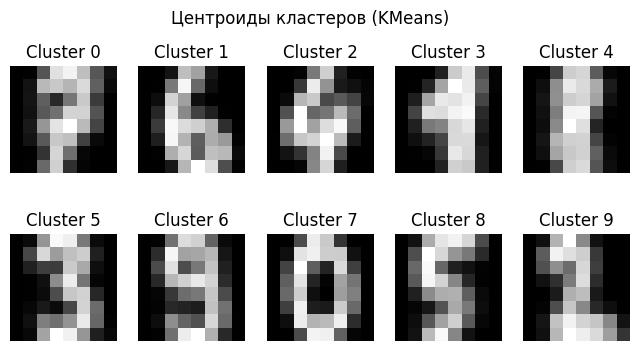

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import homogeneity_score, completeness_score, adjusted_rand_score, silhouette_score
import matplotlib.pyplot as plt

results = []
for init in ['k-means++', 'random']:
    kmeans = KMeans(n_clusters=10, init=init, n_init=20, random_state=42)
    clusters = kmeans.fit_predict(X)
    hom = homogeneity_score(y, clusters)
    comp = completeness_score(y, clusters)
    ari = adjusted_rand_score(y, clusters)
    sil = silhouette_score(X, clusters)
    results.append({
        'init': init,
        'homogeneity': hom,
        'completeness': comp,
        'ARI': ari,
        'silhouette': sil,
        'kmeans': kmeans
    })
    print(f"Init: {init}")
    print(f"Homogeneity: {hom:.3f}")
    print(f"Completeness: {comp:.3f}")
    print(f"Adjusted Rand Index: {ari:.3f}")
    print(f"Silhouette Coefficient: {sil:.3f}")
    print('-'*30)

best = max(results, key=lambda d: d['silhouette'])
print(f"Лучшая инициализация: {best['init']}")

fig, axes = plt.subplots(2, 5, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(best['kmeans'].cluster_centers_[i].reshape(8, 8), cmap='gray')
    ax.set_title(f'Cluster {i}')
    ax.axis('off')
plt.suptitle('Центроиды кластеров (KMeans)')
plt.show()

Не всегда бывает удобно работать с полной матрицей объект-признак — например, для визуализации подходят лишь выборки размерности не больше трёх. На лекциях был рассмотрен метод уменьшения размерности *PCA*. В документации sklearn есть [сравнение](http://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html#example-manifold-plot-lle-digits-py) различных способов понижения размерности для проекции на плоскость. На изображениях видно, что некоторые преобразования дают неплохую визуализацию, где одинаковые цифры расположены близко друг к другу. Посмотрим, поможет ли это на практике.
 
**2. (1 балл)** Примените преобразования [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) и [t-SNE](http://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) (для числа компонент 2 и 10), проведите кластеризацию в новых признаковых пространствах и сравните результаты с предыдущими. Нашелся ли метод кластеризации, превосходящий другие по всем метрикам? Являются ли все три метрики согласованными? Можете ли вы объяснить, почему так произошло?

PCA (2 компоненты) (init=k-means++):
  Homogeneity: 0.526
  Completeness: 0.530
  Adjusted Rand Index: 0.393
  Silhouette Coefficient: 0.394
------------------------------
PCA (10 компонент) (init=k-means++):
  Homogeneity: 0.723
  Completeness: 0.731
  Adjusted Rand Index: 0.652
  Silhouette Coefficient: 0.264
------------------------------
t-SNE (2 компоненты) (init=k-means++):
  Homogeneity: 0.911
  Completeness: 0.912
  Adjusted Rand Index: 0.888
  Silhouette Coefficient: 0.641
------------------------------
t-SNE (10 компонент) (init=k-means++):
  Homogeneity: 0.832
  Completeness: 0.840
  Adjusted Rand Index: 0.774
  Silhouette Coefficient: 0.354
------------------------------


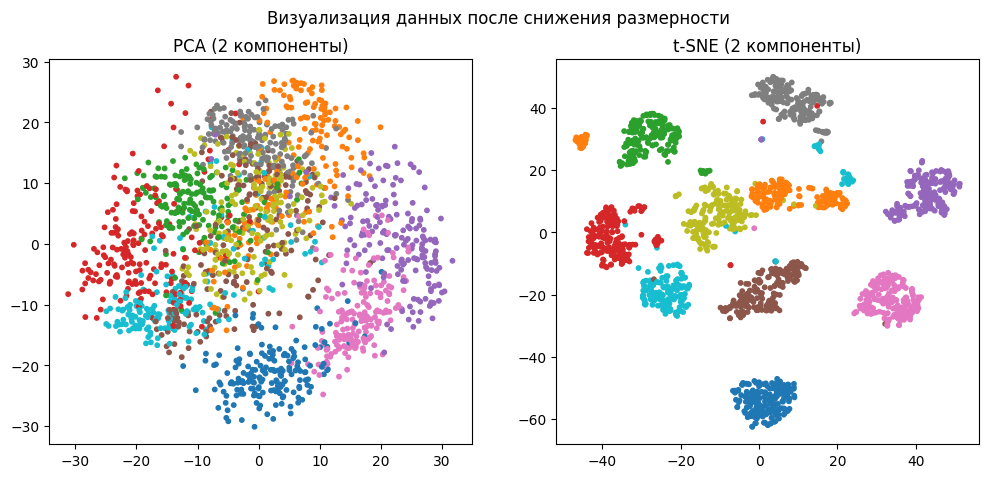

In [3]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def cluster_and_evaluate(X_proj, y, n_clusters=10, init='k-means++', name=''):
    kmeans = KMeans(n_clusters=n_clusters, init=init, n_init=20, random_state=42)
    clusters = kmeans.fit_predict(X_proj)
    hom = homogeneity_score(y, clusters)
    comp = completeness_score(y, clusters)
    ari = adjusted_rand_score(y, clusters)
    sil = silhouette_score(X_proj, clusters)
    print(f"{name} (init={init}):")
    print(f"  Homogeneity: {hom:.3f}")
    print(f"  Completeness: {comp:.3f}")
    print(f"  Adjusted Rand Index: {ari:.3f}")
    print(f"  Silhouette Coefficient: {sil:.3f}")
    print('-'*30)
    return dict(hom=hom, comp=comp, ari=ari, sil=sil)

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X)
cluster_and_evaluate(X_pca2, y, name='PCA (2 компоненты)')

pca10 = PCA(n_components=10, random_state=42)
X_pca10 = pca10.fit_transform(X)
cluster_and_evaluate(X_pca10, y, name='PCA (10 компонент)')

X_tsne2 = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto').fit_transform(X)
cluster_and_evaluate(X_tsne2, y, name='t-SNE (2 компоненты)')

X_tsne10 = TSNE(n_components=10, random_state=42, init='pca', learning_rate='auto', method='exact').fit_transform(X)
cluster_and_evaluate(X_tsne10, y, name='t-SNE (10 компонент)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y, cmap='tab10', s=10)
axes[0].set_title('PCA (2 компоненты)')
axes[1].scatter(X_tsne2[:, 0], X_tsne2[:, 1], c=y, cmap='tab10', s=10)
axes[1].set_title('t-SNE (2 компоненты)')
plt.suptitle('Визуализация данных после снижения размерности')
plt.show()

**3. (1 балл)** Визуализируйте несколько изображений, которые во всех случаях были отнесены к неправильному кластеру (объект назовем ошибочно отнесенным, если он имеет иную метку класса, нежели большая часть объектов в кластере). Можете ли вы пояснить, почему так произошло?

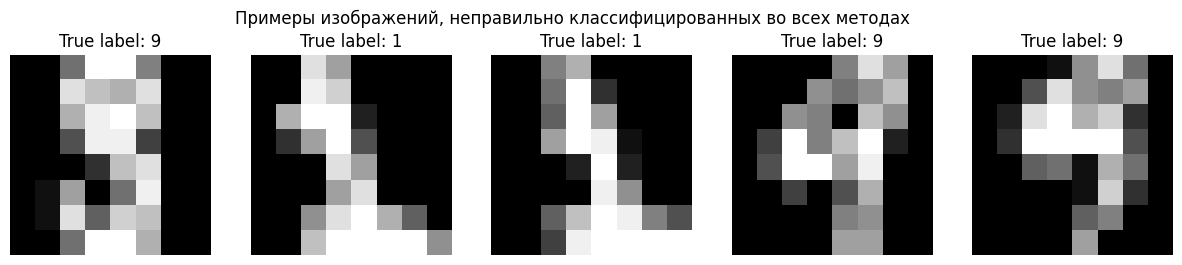

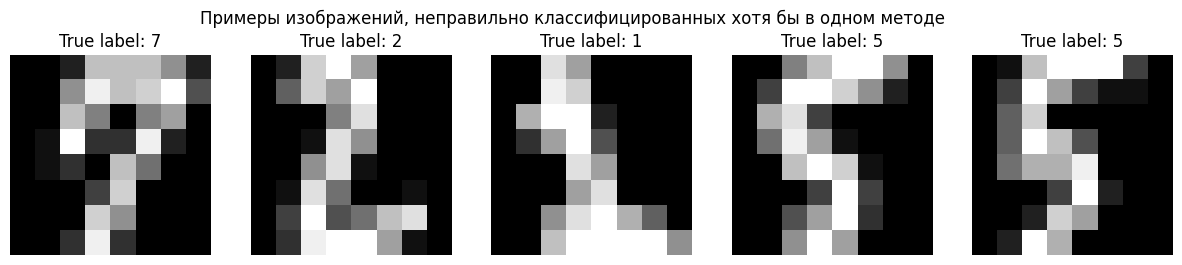

In [4]:
def get_misclassified_indices(X_proj, y, n_clusters=10, init='k-means++'):
    kmeans = KMeans(n_clusters=n_clusters, init=init, n_init=20, random_state=42)
    clusters = kmeans.fit_predict(X_proj)
    
    # Для каждого кластера найдем наиболее частую метку
    cluster_labels = {}
    for cluster in range(n_clusters):
        cluster_mask = clusters == cluster
        if np.sum(cluster_mask) > 0:
            most_common = np.bincount(y[cluster_mask]).argmax()
            cluster_labels[cluster] = most_common
    
    # Найдем объекты, которые были неправильно классифицированы
    misclassified = []
    for i in range(len(y)):
        cluster = clusters[i]
        if cluster in cluster_labels and y[i] != cluster_labels[cluster]:
            misclassified.append(i)
    
    return misclassified

# Получим индексы неправильно классифицированных объектов для каждого метода
misclassified_pca2 = set(get_misclassified_indices(X_pca2, y))
misclassified_pca10 = set(get_misclassified_indices(X_pca10, y))
misclassified_tsne2 = set(get_misclassified_indices(X_tsne2, y))

# Найдем объекты, которые были неправильно классифицированы во всех методах
common_misclassified = misclassified_pca2.intersection(misclassified_pca10, misclassified_tsne2)

# Визуализируем несколько таких объектов
n_samples = min(5, len(common_misclassified))
if n_samples > 0:
    fig, axes = plt.subplots(1, n_samples, figsize=(15, 3))
    for i, idx in enumerate(list(common_misclassified)[:n_samples]):
        axes[i].imshow(X[idx].reshape(8, 8), cmap='gray')
        axes[i].set_title(f'True label: {y[idx]}')
        axes[i].axis('off')
    plt.suptitle('Примеры изображений, неправильно классифицированных во всех методах')
    plt.show()
else:
    print("Не найдено изображений, которые были бы неправильно классифицированы во всех методах")

# Визуализируем несколько объектов, которые были неправильно классифицированы хотя бы в одном методе
all_misclassified = misclassified_pca2.union(misclassified_pca10, misclassified_tsne2)
n_samples = min(5, len(all_misclassified))
if n_samples > 0:
    fig, axes = plt.subplots(1, n_samples, figsize=(15, 3))
    for i, idx in enumerate(list(all_misclassified)[:n_samples]):
        axes[i].imshow(X[idx].reshape(8, 8), cmap='gray')
        axes[i].set_title(f'True label: {y[idx]}')
        axes[i].axis('off')
    plt.suptitle('Примеры изображений, неправильно классифицированных хотя бы в одном методе')
    plt.show()

## Разделение изображения на семантические компоненты

![RedPanda](http://imgur.com/6Aa52Lm.png)

Алгоритмы кластеризации могут применяться в самых разных целях. Например, в анализе изображений есть задача разделения изображения на семантические компоненты, которую можно решать в том числе с помощью алгоритмов кластеризации. 

Загрузите [изображения](https://disk.yandex.ru/d/Nsl0cWOsc9PO-g).

In [12]:
def visualize_segmentation(img, labels, title, n_clusters):
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap=plt.cm.gray)
    
    for l in range(n_clusters):
        plt.contour(labels == l, contours=1,
                   colors=[plt.cm.nipy_spectral(l / float(n_clusters)), ])
    
    plt.xticks(())
    plt.yticks(())
    plt.title(title)
    plt.show()

**4. (1 балл)** Для каждого изображения, используя кластеризацию KMeans, выделите компоненты, охарактеризовав каждый пиксель вектором признаков $\psi_i = [\lambda x_i, \lambda y_i, r_i, g_i, b_i]$, где 
$x_i$ и $y_i$ — координаты пикселя, $r_i, g_i, b_i$ — его цвет, $\lambda$ — параметр, выражающий важность пространственной связности перед цветовой похожестью.

In [ ]:
from PIL import Image
import os
import time

def segment_image_kmeans(img_path, n_clusters=5, lambda_spatial=0.1):
    pil_img = Image.open(img_path)
    img = np.array(pil_img)
    
    h, w = img.shape[:2]
    
    y, x = np.mgrid[0:h, 0:w]
    
    x = x / w
    y = y / h
    
    r = img[:,:,0] / 255.0
    g = img[:,:,1] / 255.0
    b = img[:,:,2] / 255.0
    
    features = np.column_stack([
        lambda_spatial * x.ravel(),
        lambda_spatial * y.ravel(),
        r.ravel(),
        g.ravel(),
        b.ravel()
    ])
    
    t0 = time.time()
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(features)
    t1 = time.time()

    visualize_segmentation(img, labels.reshape(h, w), 
                         f'KMeans сегментация: {t1-t0:.2f}с', n_clusters)

image_files = [f for f in os.listdir('images') if f.endswith(('.jpg', '.jpeg', '.png'))]

n_clusters = 5
lambda_spatial = 0.1

for img_file in image_files:
    segment_image_kmeans(os.path.join('images', img_file), n_clusters, lambda_spatial)

**5. (1 балл)** Попробуйте выделить сегменты при помощи [спектральной кластеризации](http://scikit-learn.org/stable/modules/clustering.html#spectral-clustering). Обратите внимание на [пример в sklearn](http://scikit-learn.org/0.16/auto_examples/cluster/plot_lena_segmentation.html). Для ускорения работы алгоритма рекомендуется привести изображение к серому цвету. При необходимости можно сжать изображения в 2 раза.

In [ ]:
from sklearn.cluster import SpectralClustering

def segment_image_spectral(img_path, n_clusters=5, n_neighbors=10):
    pil_img = Image.open(img_path)
    img = np.array(pil_img)
    
    h, w = img.shape[:2]
    new_h, new_w = h//2, w//2
    pil_img = pil_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    img = np.array(pil_img)
    
    if len(img.shape) == 3:
        gray_img = np.mean(img, axis=2)
    else:
        gray_img = img
    
    gray_img = gray_img / 255.0
    
    features = gray_img.reshape(-1, 1)

    t0 = time.time()
    spectral = SpectralClustering(
        n_clusters=n_clusters,
        affinity='nearest_neighbors',
        n_neighbors=n_neighbors,
        random_state=42
    )
    labels = spectral.fit_predict(features)
    t1 = time.time()
    
    visualize_segmentation(gray_img, labels.reshape(new_h, new_w),
                         f'Спектральная сегментация: {t1-t0:.2f}с', n_clusters)

image_files = [f for f in os.listdir('images') if f.endswith(('.jpg', '.jpeg', '.png'))]

n_clusters = 5
lambda_spatial = 0.1

for img_file in image_files:
    print(f"\nОбработка {img_file}...")
    segment_image_spectral(os.path.join('images', img_file), n_clusters)

**6. (1 балл)** Визуализируйте результаты сегментации (аналогично рисунку выше) для обоих методов. [Пример кода для визуализации](http://scikit-learn.org/0.16/auto_examples/cluster/plot_lena_segmentation.html).

In [ ]:
выше

**7. (1 балл)** Поэкспериментируйте с параметрами алгоритмов и параметром $\lambda$ в признаках. Сравните два подхода и сегментации, к которым они приводят.
Для всех ли изображений в результате сегментации хорошо видны контуры объектов?

In [ ]:
n_clusters_list = [3, 5, 7, 10]
lambda_values = [0.01, 0.1, 1.0]
n_neighbors_list = [5, 10, 20]

for n_clusters in n_clusters_list:
    for lambda_spatial in lambda_values:
        print("Кластеры: ", n_clusters, "lambda: ", lambda_spatial)
        segment_image_kmeans('images\pets1.jpg', n_clusters, lambda_spatial)

for n_clusters in n_clusters_list:
    for n_neighbors in n_neighbors_list:
        print("Кластеры: ", n_clusters, "neighdors: ", n_neighbors)
        segment_image_spectral('images\pets1.jpg', n_clusters, n_neighbors)

Измерять качество сегментации в этом пункте не нужно, в результате ожидаются только картинки и выводы.

### Рекомендации к выполнению
Для работы с изображениями удобно использовать библиотеку [Scikit-Image](http://scikit-image.org). 
Установите [PIL](http://www.pythonware.com/products/pil/) для возможности чтения формата JPG.

Пример чтения изображения в матрицу [картинки](https://images.wallpapersden.com/image/download/4k-planet-pixel-art_bGprbGqUmZqaraWkpJRqZmetamZn.jpg):

    import matplotlib.pyplot as plt
    from skimage.io import imread

    I = imread("wallpapersden.com_k-planet-pixel-art_512x512.jpg") 

    plt.figure(figsize=(15, 5))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(I[:,:,i])

## Word2vec

**8. (3 балла)**
1. [Скачайте данные](https://www.kaggle.com/c/word2vec-nlp-tutorial/data). Если не получается, можно скачать и работать с [этими данными](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews).
2. [Установите необходимые библиотеки](https://www.kaggle.com/c/word2vec-nlp-tutorial/details/setting-up-your-system)
3. Внимательно изучите тьториалы, доступные в рамках контеста [Part 1](https://www.kaggle.com/c/word2vec-nlp-tutorial/details/part-1-for-beginners-bag-of-words) – [Part 4](https://www.kaggle.com/c/word2vec-nlp-tutorial/details/part-4-comparing-deep-and-non-deep-learning-methods). Эти статьи очень полезны для понимания принципов анализа текстовых данных в питоне.
4. Согласно тьюториалам подготовить данные и обучить модель word2vec. Полезно засечь время обучения модели.
5. Протестировать модель на датасете, подготовленном Google, с задачами вида: *London → England*, значит, *Berlin → Germany*. Пример вызова нужной функции и описание датасета есть [тьюториале по word2vec](https://rare-technologies.com/word2vec-tutorial/). Сам датасет можно скачать по [ссылке](https://www.dropbox.com/s/prb8n5b5na5qo07/questions-words.txt?dl=0). С чем может быть связано большое число неверных ответов?
6. Привести по 5-10 примеров для задачи поиска лишнего слова *(model.doesnt_match)* и для задачи поиска семантически близких слов *(model.most_similar)*. Проинтерпретировать полученные результаты. Все ли примеры соответствуют здравому смыслу? По каким принципам группируются близкие слова в выбранных вами примерах?

In [34]:
import os
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np


train = pd.read_csv('labeledTrainData.tsv', header=0, delimiter="\t", quoting=3)
test = pd.read_csv('testData.tsv', header=0, delimiter="\t", quoting=3)

print('The first review is:')
print(train["review"][0])

def clean_text(text):
    text = text.replace('<br />', ' ')
    text = ''.join([c.lower() for c in text if c.isalpha() or c.isspace()])
    words = text.split()
    return ' '.join(words)

clean_train_reviews = []
for review in train["review"]:
    clean_train_reviews.append(clean_text(review))


vectorizer = CountVectorizer(analyzer = "word",
                            tokenizer = None,
                            preprocessor = None,
                            stop_words = None,
                            max_features = 5000)

train_data_features = vectorizer.fit_transform(clean_train_reviews)
# train_data_features = np.asarray(train_data_features)

forest = RandomForestClassifier(n_estimators = 100, random_state=42)
forest = forest.fit( train_data_features, train["sentiment"] )

print("Cleaning and parsing the test set movie reviews...\n")
clean_test_reviews = []
for review in test["review"]:
    clean_test_reviews.append(clean_text(review))

test_data_features = vectorizer.transform(clean_test_reviews)
# test_data_features = np.asarray(test_data_features)

result = forest.predict(test_data_features)

output = pd.DataFrame(data={"id": test["id"], "sentiment": result})
output.to_csv('data/Bag_of_Words_model.csv', index=False, quoting=3)
print("Wrote results to Bag_of_Words_model.csv")


The first review is:
"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bi

KeyboardInterrupt: 

In [36]:
import nltk
from nltk.corpus import stopwords
import nltk.data
import logging
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')
nltk.download('stopwords')

class KaggleWord2VecUtility:
    @staticmethod
    def review_to_wordlist(review, remove_stopwords=False):
        review = review.replace('<br />', ' ')
        review = ''.join([c.lower() for c in review if c.isalpha() or c.isspace()])
        words = review.split()
        if remove_stopwords:
            stops = set(stopwords.words("english"))
            words = [w for w in words if w not in stops]
        return ' '.join(words)

def getCleanReviews(reviews):
    clean_reviews = []
    for review in reviews["review"]:
        clean_reviews.append(KaggleWord2VecUtility.review_to_wordlist(review, remove_stopwords=True))
    return clean_reviews


train = pd.read_csv('labeledTrainData.tsv', header=0, delimiter="\t", quoting=3)
test = pd.read_csv('testData.tsv', header=0, delimiter="\t", quoting=3)

print(f"Read {train['review'].size} labeled train reviews, {test['review'].size} labeled test reviews\n")

print("Cleaning and parsing the training set movie reviews...")
clean_train_reviews = getCleanReviews(train)
clean_test_reviews = getCleanReviews(test)

print("Creating TF-IDF vectors...")
vectorizer = TfidfVectorizer(max_features=5000)
train_data_features = vectorizer.fit_transform(clean_train_reviews)
test_data_features = vectorizer.transform(clean_test_reviews)

forest = RandomForestClassifier(n_estimators=100, random_state=42)
print("Fitting a random forest to labeled training data...")
forest = forest.fit(train_data_features, train["sentiment"])

result = forest.predict(test_data_features)

output = pd.DataFrame(data={"id": test["id"], "sentiment": result})
output.to_csv("TFIDF_RandomForest.csv", index=False, quoting=3)
print("Wrote TFIDF_RandomForest.csv")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Red\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Red\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Read 25000 labeled train reviews, 25000 labeled test reviews

Cleaning and parsing the training set movie reviews...
Creating TF-IDF vectors...
Fitting a random forest to labeled training data...


KeyboardInterrupt: 